# Autograd & the Training Loop
This notebook answers: **how does a neural network actually learn?**

The answer is gradients. PyTorch tracks every operation on a tensor and can automatically compute how each weight contributed to the final loss.

## 1. What is a Gradient?
A gradient tells you: *if I change this value a little, how much does the loss change?*
PyTorch computes this automatically with `requires_grad=True`.

In [1]:
import torch

# A simple example: y = x^2, dy/dx = 2x
x = torch.tensor(3.0, requires_grad=True)
y = x ** 2
y.backward()   # compute gradients

print("x      =", x.item())
print("y      =", y.item())
print("dy/dx  =", x.grad.item())   # should be 2*3 = 6


x      = 3.0
y      = 9.0
dy/dx  = 6.0


In [3]:
# TODO: Compute the gradient of y = x^3 at x = 2.0
#       The answer should be 3 * 2^2 = 12
t=torch.tensor(2.0,requires_grad=True)
r=t**3
r.backward()
print("gradient",t.grad.item())


gradient 12.0


## 2. A Simple Linear Model
Let's build the simplest possible model by hand: `y_pred = w * x + b`.
We'll learn `w` and `b` from data using gradient descent.

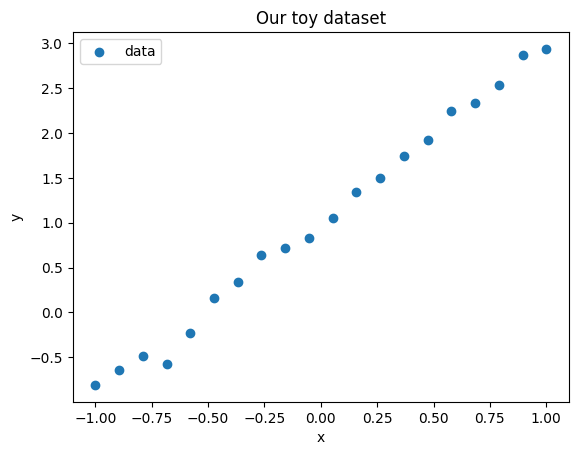

In [4]:
import matplotlib.pyplot as plt

torch.manual_seed(42)

# True relationship we want the model to discover: y = 2x + 1
X = torch.linspace(-1, 1, 20).unsqueeze(1)   # shape (20, 1)
y = 2 * X + 1 + 0.1 * torch.randn_like(X)    # add a tiny bit of noise

plt.scatter(X, y, label="data")
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.title("Our toy dataset")
plt.show()


In [13]:
# Initialise learnable parameters
w = torch.randn(1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

lr = 0.01   # learning rate
losses = []

for epoch in range(100):
    # Forward pass
    y_pred = w * X + b

    # Loss: Mean Squared Error
    loss = ((y_pred - y) ** 2).mean()
    losses.append(loss.item())

    # Backward pass — compute gradients
    loss.backward()

    # Update weights (gradient descent step)
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad

    # Zero gradients before next iteration — IMPORTANT
    w.grad.zero_()
    b.grad.zero_()

print(f"Learned w = {w.item():.3f}  (true = 2.0)")
print(f"Learned b = {b.item():.3f}  (true = 1.0)")


Learned w = 1.400  (true = 2.0)
Learned b = 0.886  (true = 1.0)


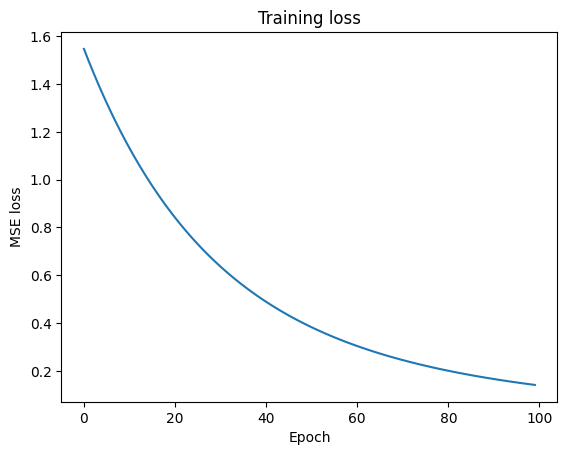

In [15]:
plt.plot(losses)
plt.xlabel("Epoch"); plt.ylabel("MSE loss"); plt.title("Training loss")
plt.show()

# TODO: Change the learning rate to 0.01 and rerun. What happens to the loss curve?
#       Then try 0.5. What happens? Write your observations as a comment below.
# if the learning rate is too small then the training will also be very slow and to converge fot minimum loses
#the epochs needed will be more


## 3. Using torch.optim
In practice you never update weights manually. `torch.optim` handles it.

In [17]:
w = torch.randn(1, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

optimizer = torch.optim.Adam([w, b], lr=0.1)
losses = []

for epoch in range(100):
    y_pred = w * X + b
    loss = ((y_pred - y) ** 2).mean()
    losses.append(loss.item())

    optimizer.zero_grad()   # zero gradients
    loss.backward()         # compute gradients
    optimizer.step()        # update weights

print(f"Learned w = {w.item():.3f}  (true = 2.0)")
print(f"Learned b = {b.item():.3f}  (true = 1.0)")

# TODO: Replace Adam with torch.optim.SGD and compare the final w and b.
#       Which converges faster?
optimizer1 = torch.optim.SGD([w, b], lr=0.1)
losses1 = []

for epoch in range(100):
    y_pred1 = w * X + b
    loss1 = ((y_pred1 - y) ** 2).mean()
    losses1.append(loss1.item())

    optimizer1.zero_grad()   # zero gradients
    loss1.backward()         # compute gradients
    optimizer1.step()        # update weights

print(f"Learned w = {w.item():.3f}  (true = 2.0)")
print(f"Learned b = {b.item():.3f}  (true = 1.0)")


Learned w = 1.957  (true = 2.0)
Learned b = 1.020  (true = 1.0)
Learned w = 1.953  (true = 2.0)
Learned b = 1.022  (true = 1.0)


## 4. The Training Loop Pattern
Every training loop in Scribe — and in deep learning generally — follows this exact pattern:

In [ ]:
# This is the skeleton you will use for every model in this project.
# Read it carefully. Understand each step.

# for epoch in range(num_epochs):
#
#     y_pred = model(X)          # 1. Forward pass
#     loss   = loss_fn(y_pred, y)  # 2. Compute loss
#
#     optimizer.zero_grad()      # 3. Zero old gradients
#     loss.backward()            # 4. Compute new gradients
#     optimizer.step()           # 5. Update weights

print("Training loop pattern — memorise this.")


## Done!
You now understand gradients, `.backward()`, and the training loop.
Next: **mlp_from_scratch.ipynb** — building a real model with `nn.Module`.